In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from PIL import Image
import time

In [5]:
#Patient data audit
len(df)

112120

In [4]:


df = pd.read_csv(r"data\data\Data_Entry_2017.csv")

print("Demographic integrity")

#age outliers (anythign over 100 is lika a data entry issue)
age_max_threshold=100
impossible_ages= df[df["Patient Age"]>age_max_threshold]
print(f"Found {len(impossible_ages)} records with age >{age_max_threshold}")

len(df)

Demographic integrity
Found 16 records with age >100


112120

In [22]:
df['Patient Age'].isnull().sum()

np.int64(0)


Number of diseases per X-ray:
disease_count
0    60361
1    30963
2    14306
3     4856
4     1247
5      301
6       67
7       16
8        1
9        2
Name: count, dtype: int64


C:\Users\Abcom\AppData\Local\Temp\ipykernel_9500\2317694002.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cardinality_stats.index,y=cardinality_stats.values,ax=ax[1],palette="viridis")


Text(0, 0.5, 'Count (Log)')

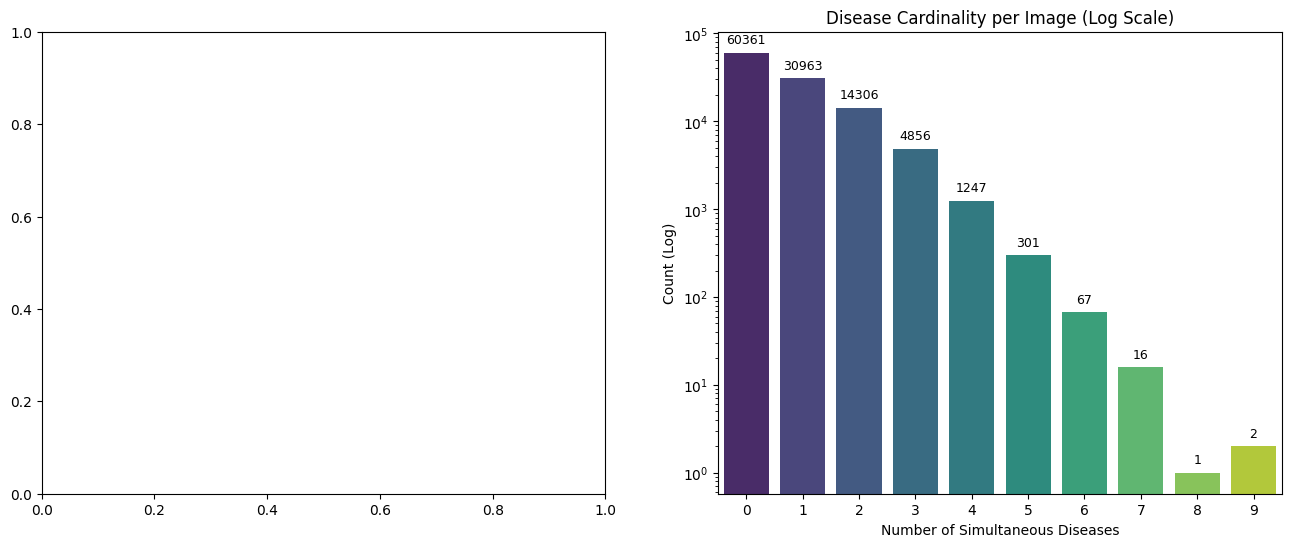

In [6]:
#counting disease listed per image
df['disease_count']=df['Finding Labels'].apply(lambda x:0 if x=="No Finding" else len(x.split("|")))

#statistics of cardinality
cardinality_stats = df['disease_count'].value_counts().sort_index()
print("\nNumber of diseases per X-ray:")
print(cardinality_stats)

#cardinality (how multi label is our task)


fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x=cardinality_stats.index,y=cardinality_stats.values,ax=ax[1],palette="viridis")

# This allows us to see the 'bars' for 4, 5, 6 diseases which are otherwise invisible
ax[1].set_yscale("log")

#add lables on bars
for p in ax[1].patches:
    height = p.get_height()
    if height > 0: # Avoid annotating empty/zero bars
        ax[1].annotate(format(height, '.0f'), 
                       (p.get_x() + p.get_width() / 2., height), 
                       ha = 'center', va = 'center', 
                       xytext = (0, 9), 
                       textcoords = 'offset points',
                       fontsize=9)

ax[1].set_title("Disease Cardinality per Image (Log Scale)")
ax[1].set_xlabel("Number of Simultaneous Diseases")
ax[1].set_ylabel("Count (Log)")

Finding Labels
No Finding            60361
Infiltration          19894
Effusion              13317
Atelectasis           11559
Nodule                 6331
Mass                   5782
Pneumothorax           5302
Consolidation          4667
Pleural_Thickening     3385
Cardiomegaly           2776
Emphysema              2516
Edema                  2303
Fibrosis               1686
Pneumonia              1431
Hernia                  227
Name: count, dtype: int64
Finding Labels
No Finding            53.836068
Infiltration          17.743489
Effusion              11.877453
Atelectasis           10.309490
Nodule                 5.646629
Mass                   5.156975
Pneumothorax           4.728862
Consolidation          4.162504
Pleural_Thickening     3.019087
Cardiomegaly           2.475919
Emphysema              2.244024
Edema                  2.054049
Fibrosis               1.503746
Pneumonia              1.276311
Hernia                 0.202462
Name: count, dtype: float64


C:\Users\Abcom\AppData\Local\Temp\ipykernel_9500\2254315164.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_freq_pct.values, y=label_freq_pct.index, palette="viridis")


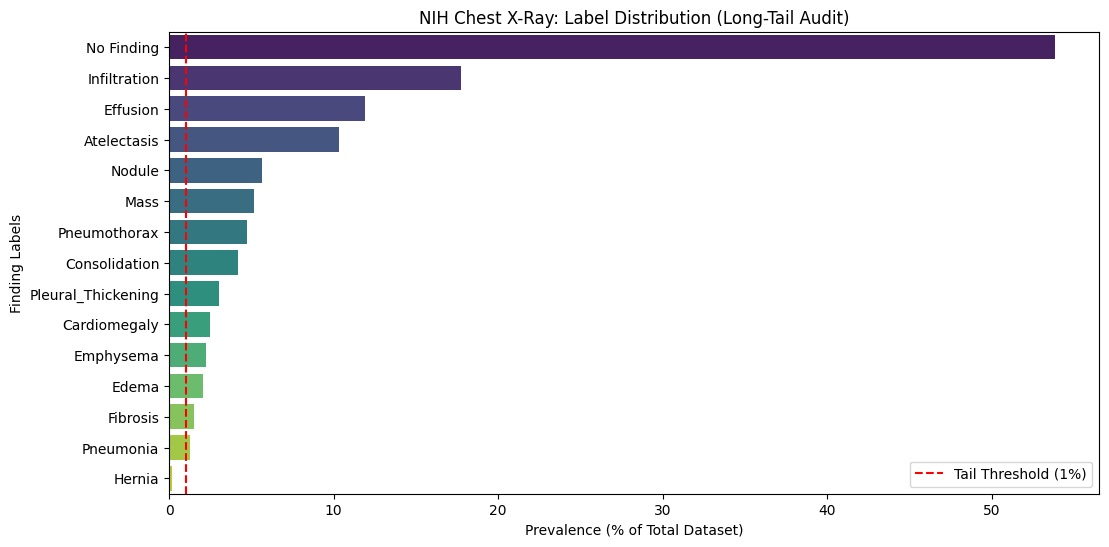

In [7]:

# Multi-Label Processing 
# Explode the labels so we can count them individually
all_labels = df['Finding Labels'].str.split('|').explode()
label_counts = all_labels.value_counts()
print(label_counts)
total_records=len(df['Finding Labels'])
label_freq_pct = (label_counts / total_records) * 100 # % of patients having this disease
print(label_freq_pct)


# Identify Head and Long Tail 
# Senior Strategy: We define "Tail" as any disease appearing in < 1% of the total population
threshold_pct = 1.0 
head_classes = label_freq_pct[label_freq_pct >= threshold_pct].index.tolist()
tail_classes = label_freq_pct[label_freq_pct < threshold_pct].index.tolist()


# Visualization (The Scientist's Proof)
plt.figure(figsize=(12, 6))
sns.barplot(x=label_freq_pct.values, y=label_freq_pct.index, palette="viridis")
plt.axvline(x=threshold_pct, color='red', linestyle='--', label='Tail Threshold (1%)')
plt.title("NIH Chest X-Ray: Label Distribution (Long-Tail Audit)")
plt.xlabel("Prevalence (% of Total Dataset)")
plt.legend()
plt.show()

In [8]:
#missing values
missing_data=df['Finding Labels'].isnull().sum()
print(missing_data)
empty_strings= (df['Finding Labels'].str.strip()=="").sum()
print(empty_strings)

0
0


{'Total Images': 112120, 'Unique Patients': 30805, 'Average Images per Patient': np.float64(3.639668884921279), 'Median Images per Patient': np.float64(1.0), 'Max Images for a single Patient': np.int64(184), 'Patients with only 1 Image': np.int64(17503)}
Total Images:112120
Unique Patients:30805
Average Images per Patient:3.639669
Median Images per Patient:1.000000
Max Images for a single Patient:184
Patients with only 1 Image:17503


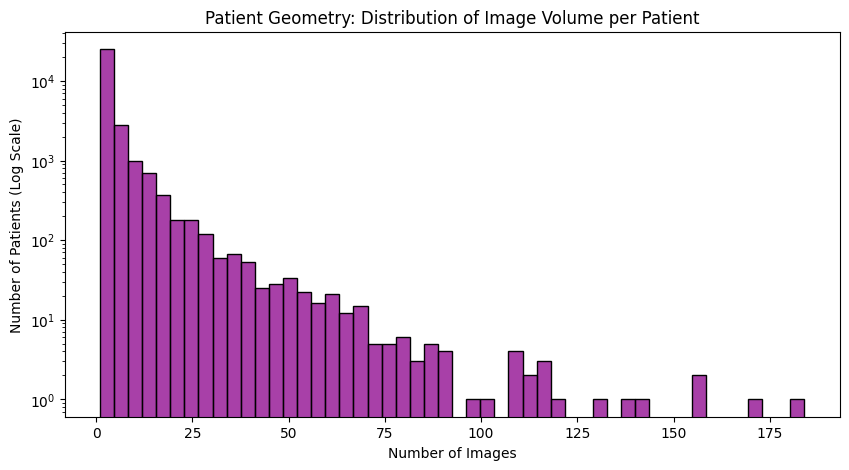

In [9]:
#patient continuity check- Patient Geometry & Leakage Check
# How many images do patients have on average? 

patient_counts = df['Patient ID'].value_counts()

#keys stats 
stats = {
    "Total Images": len(df),
    "Unique Patients": len(patient_counts),
    "Average Images per Patient": patient_counts.mean(),
    "Median Images per Patient": patient_counts.median(),
    "Max Images for a single Patient": patient_counts.max(),
    "Patients with only 1 Image": (patient_counts == 1).sum()
}
print(stats)

for key,value in stats.items():
    print(f"{key}:{value:2F}" if isinstance(value,float) else f"{key}:{value}")

#visualize the patient tail
plt.figure(figsize=(10,5))
sns.histplot(patient_counts,bins=50,kde=False,color='darkmagenta')
plt.yscale('log')
plt.title("Patient Geometry: Distribution of Image Volume per Patient")
plt.xlabel("Number of Images")
plt.ylabel("Number of Patients (Log Scale)")
plt.show()


In [10]:
#View Position Discovery (Biased Feature Detection) 
# Check if certain diseases are 'locked' to certain camera angles
view_pos = df.groupby('View Position')['Finding Labels'].count()
print("View Position Breakdown:")
print(view_pos)

View Position Breakdown:
View Position
AP    44810
PA    67310
Name: Finding Labels, dtype: int64


        Atelectasis  Cardiomegaly  Consolidation  Edema  Effusion  Emphysema  \
0                 0             1              0      0         0          0   
1                 0             1              0      0         0          1   
2                 0             1              0      0         1          0   
3                 0             0              0      0         0          0   
4                 0             0              0      0         0          0   
...             ...           ...            ...    ...       ...        ...   
112115            0             0              0      0         0          0   
112116            0             0              0      0         0          0   
112117            0             0              0      0         0          0   
112118            0             0              0      0         0          0   
112119            0             0              0      0         0          0   

        Fibrosis  Hernia  Infiltration 

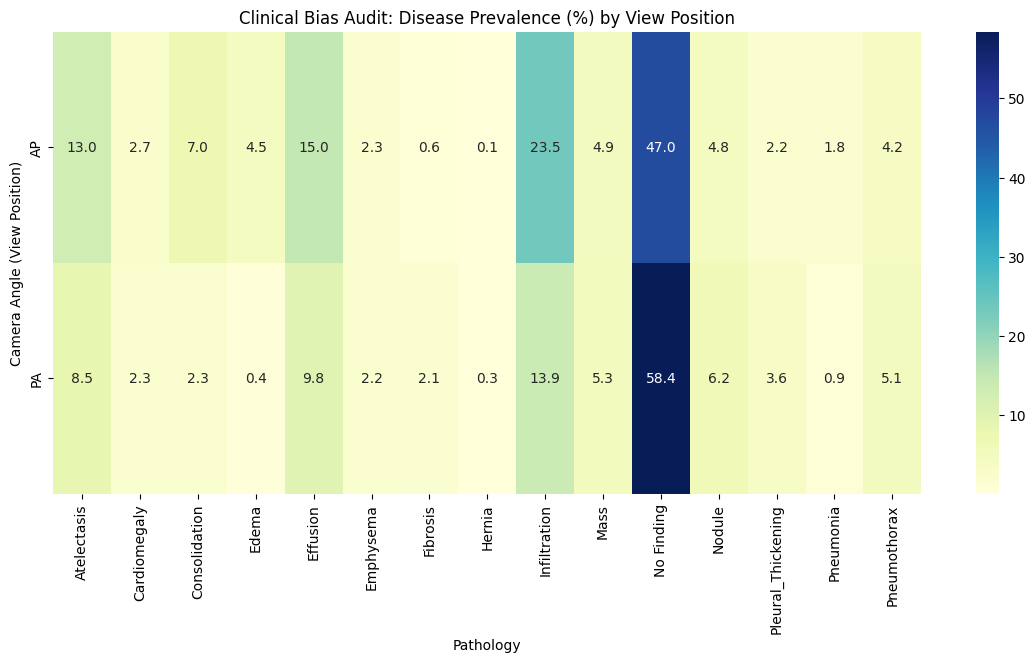

In [23]:
all_disease_cols = df['Finding Labels'].str.get_dummies(sep='|')
print(all_disease_cols)
all_disease_cols['View Position'] = df['View Position']

# Calculate the mean occurrence of each disease per View Position
bias_audit = all_disease_cols.groupby('View Position').mean() * 100
print(bias_audit)

# Visualize as a Heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(bias_audit, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Clinical Bias Audit: Disease Prevalence (%) by View Position")
plt.xlabel("Pathology")
plt.ylabel("Camera Angle (View Position)")
plt.show()

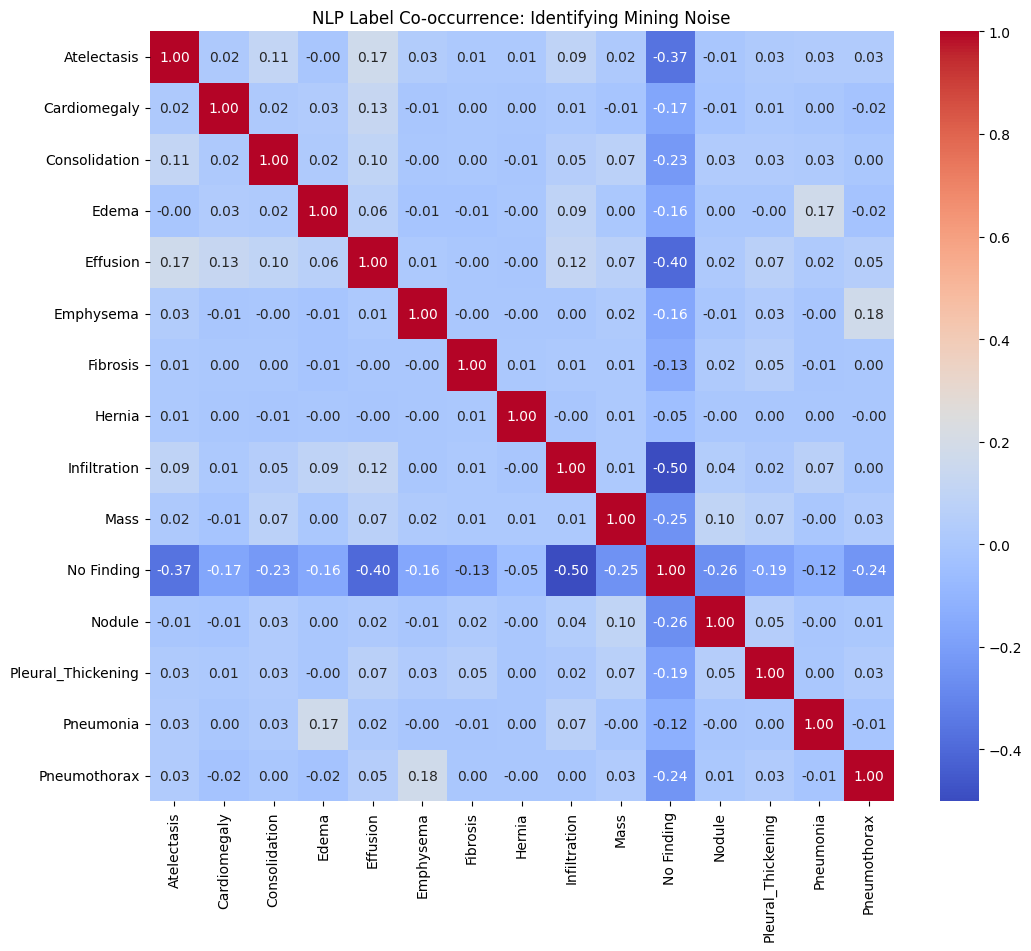

In [15]:

labels_binary = df['Finding Labels'].str.get_dummies(sep='|')

#calculate correlation matrix
correlation_matrix= labels_binary.corr()

#identify scientific noise
#high correlation between mutually exclusive diseases indicated nlp mining errors

plt.figure(figsize=(12,10))
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm',fmt=".2f")
plt.title("NLP Label Co-occurrence: Identifying Mining Noise")
plt.show()



In [19]:
#calculate percentage of no findings combined with other labels

df['disease_count']= df['Finding Labels'].apply(lambda x:0 if x =="No Finding" else len(x.split('|')))
print(df['disease_count'])

#identify logical impossible rows
logical_noise= df[(df['Finding Labels'].str.contains('No Finding')) & (df['disease_count']>0)]

#calculate noise pct

noise_pct= (len(logical_noise)/len(df))*100
print(f"📊 Audit Results:")
print(f"- Records with 'No Finding' + Disease: {len(logical_noise)}")
print(f"- Total NLP Logical Noise: {noise_pct:.4f}%")

if len(logical_noise)>0:
    print("\n exmaple of noise (nlp errors):")
    print(logical_noise['Finding Labels'].head())


0         1
1         2
2         2
3         0
4         1
         ..
112115    2
112116    0
112117    0
112118    0
112119    0
Name: disease_count, Length: 112120, dtype: int64
📊 Audit Results:
- Records with 'No Finding' + Disease: 0
- Total NLP Logical Noise: 0.0000%


In [ ]:
#spatial discovery audit

In [28]:

print("\n Spatial audit")
adi_df=pd.read_csv(r'data\data\WI_2023_ADI_9 Digit Zip Code_v4_0_1.csv')
print(f"ADI neighborhoods:{len(adi_df)}")

#CHCEK FOR MISSING VALUES
missing_val= adi_df['ADI_STATERNK'].isnull().sum()
total_val= len(adi_df)
print(missing_val)
print(f"percentage of missing vals:{(missing_val/total_val)*100:.2f}%")


 Spatial audit
ADI neighborhoods:1048575
11
percentage of missing vals:0.00%


In [ ]:
#find non numeric values in adi
noise_count= pd.to_numeric(adi_df["ADI_STATERNK"],errors="coerce").isna().sum()
print(f"dirty data (non numeric ranks):{noise_count},{len(adi_df)}")

dirty data (non numeric ranks):143606,1048575


In [27]:
#statistical summary of adi
print(adi_df['ADI_STATERNK'].describe())


count     1048564
unique         16
top             5
freq       105780
Name: ADI_STATERNK, dtype: object


In [30]:
#chcek for duplicated values

print(adi_df[['ZIP_4', 'ADI_STATERNK', 'ADI_NATRANK']].head())

duplicates=adi_df.duplicated(subset=['ZIP_4']).sum()
print(duplicates)

       ZIP_4 ADI_STATERNK ADI_NATRANK
0  530010001            4          54
1  530010002            4          54
2  530010003            4          54
3  530010004            4          54
4  530010005            4          54
0


ADI_STATERNK
1         88534
10        58458
2         97138
3        101522
4        100392
5        105780
6         96013
7         77795
8         98597
9         80740
GQ         7407
GQ-PH       117
P         75598
PH          102
QDI         784
U         59587
Name: count, dtype: int64


C:\Users\Abcom\AppData\Local\Temp\ipykernel_10672\855990570.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=adi_counts.index, y=adi_counts.values, palette="coolwarm")


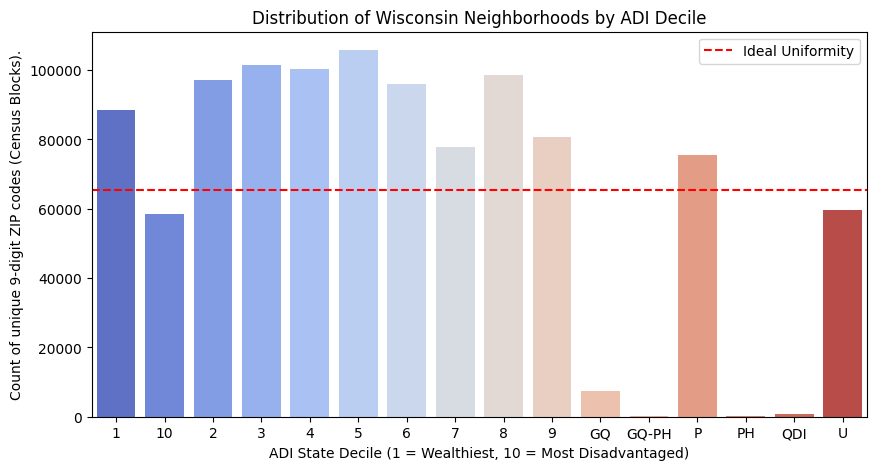

In [31]:

# 3. Analyze Distribution (The Scientific Check)

#rank distribution
adi_counts= adi_df['ADI_STATERNK'].value_counts().sort_index() 
print(adi_counts)

plt.figure(figsize=(10, 5))
sns.barplot(x=adi_counts.index, y=adi_counts.values, palette="coolwarm")
plt.title("Distribution of Wisconsin Neighborhoods by ADI Decile")
plt.xlabel("ADI State Decile (1 = Wealthiest, 10 = Most Disadvantaged)")
plt.ylabel("Count of unique 9-digit ZIP codes (Census Blocks).")
plt.axhline(adi_df['ADI_STATERNK'].value_counts().mean(), color='red', linestyle='--', label='Ideal Uniformity')
plt.legend()
plt.show()

In [ ]:
#image integrity and resolution profiling

In [33]:
#which disease actually have bounding boxes
    
bbox=pd.read_csv(r"data\data\BBox_List_2017.csv")
bbox_diseases= bbox['Finding Label'].value_counts()
print("\nDiseases with BBox support:")
print(bbox_diseases)


Diseases with BBox support:
Finding Label
Atelectasis     180
Effusion        153
Cardiomegaly    146
Infiltrate      123
Pneumonia       120
Pneumothorax     98
Mass             85
Nodule           79
Name: count, dtype: int64


In [34]:

#verify coordinate boundaries
out_of_bounds = bbox[(bbox['Bbox [x'] + bbox['w'] > 1024) | (bbox['y'] + bbox['h]'] > 1024)]
print(f"Coordinate Integrity: {'OK' if out_of_bounds.empty else 'Out of Bounds Found'}") 


Coordinate Integrity: OK


In [40]:
#visual and hardware auidt

req_images=set()
req_images= set(df['Image Index'].unique())
image_location_map={}

#recursive scan through all1 3 folders
for root,dirs,files in os.walk("data\images"):
    for file in files:
        if file.endswith(".png"):
            image_location_map[file]=os.path.abspath(os.path.join(root,file))

found_images= set(image_location_map.keys())
matched= req_images.intersection(found_images)

     
print(f"Total Images Required: {len(req_images)}")
print(f"Total Images Found: {len(found_images)}")
print(f"Linkage Success: {len(matched)} / {len(req_images)}")


#hardware and latecny abseline
if matched:
    print("hardware performance abseline")
    sample_key=list(matched)[0]

    s=time.time()

    with Image.open(image_location_map[sample_key]) as img:
        res=img.size
        mode=img.mode
    latency= (time.time()-s)*1000

    print(f"Resolution:{res} | Mode :{mode}")
    print(f"Disk-to-ram latency:{latency:.2f}ms per image")

Total Images Required: 112120
Total Images Found: 107552
Linkage Success: 107552 / 112120
hardware performance abseline
Resolution:(1024, 1024) | Mode :L
Disk-to-ram latency:16.24ms per image
